In [1]:
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2024-04-12 03:25:29--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  1.35MB/s    in 3.6s    

2024-04-12 03:25:34 (1.35 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import nltk
import textwrap

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [17]:
 nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
stops = set(stopwords.words('english'))

In [21]:
stops = stops.union({
    'said', 'would', 'could', 'told', 'also', 'one', 'two',
    'mr','new', 'year'
})

In [22]:
df = pd.read_csv('bbc_text_cls.csv')

In [23]:
df

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business
...,...,...
2220,BT program to beat dialler scams\n\nBT is intr...,tech
2221,Spam e-mails tempt net shoppers\n\nComputer us...,tech
2222,Be careful how you code\n\nA new European dire...,tech
2223,US cyber security chief resigns\n\nThe man mak...,tech


In [27]:
vectorizer = CountVectorizer(stop_words='english')


In [28]:
X = vectorizer.fit_transform(df['text'])

In [29]:
lda = LatentDirichletAllocation(
    n_components = 10,
    random_state = 12345
)

In [30]:
lda.fit(X)

LatentDirichletAllocation(random_state=12345)

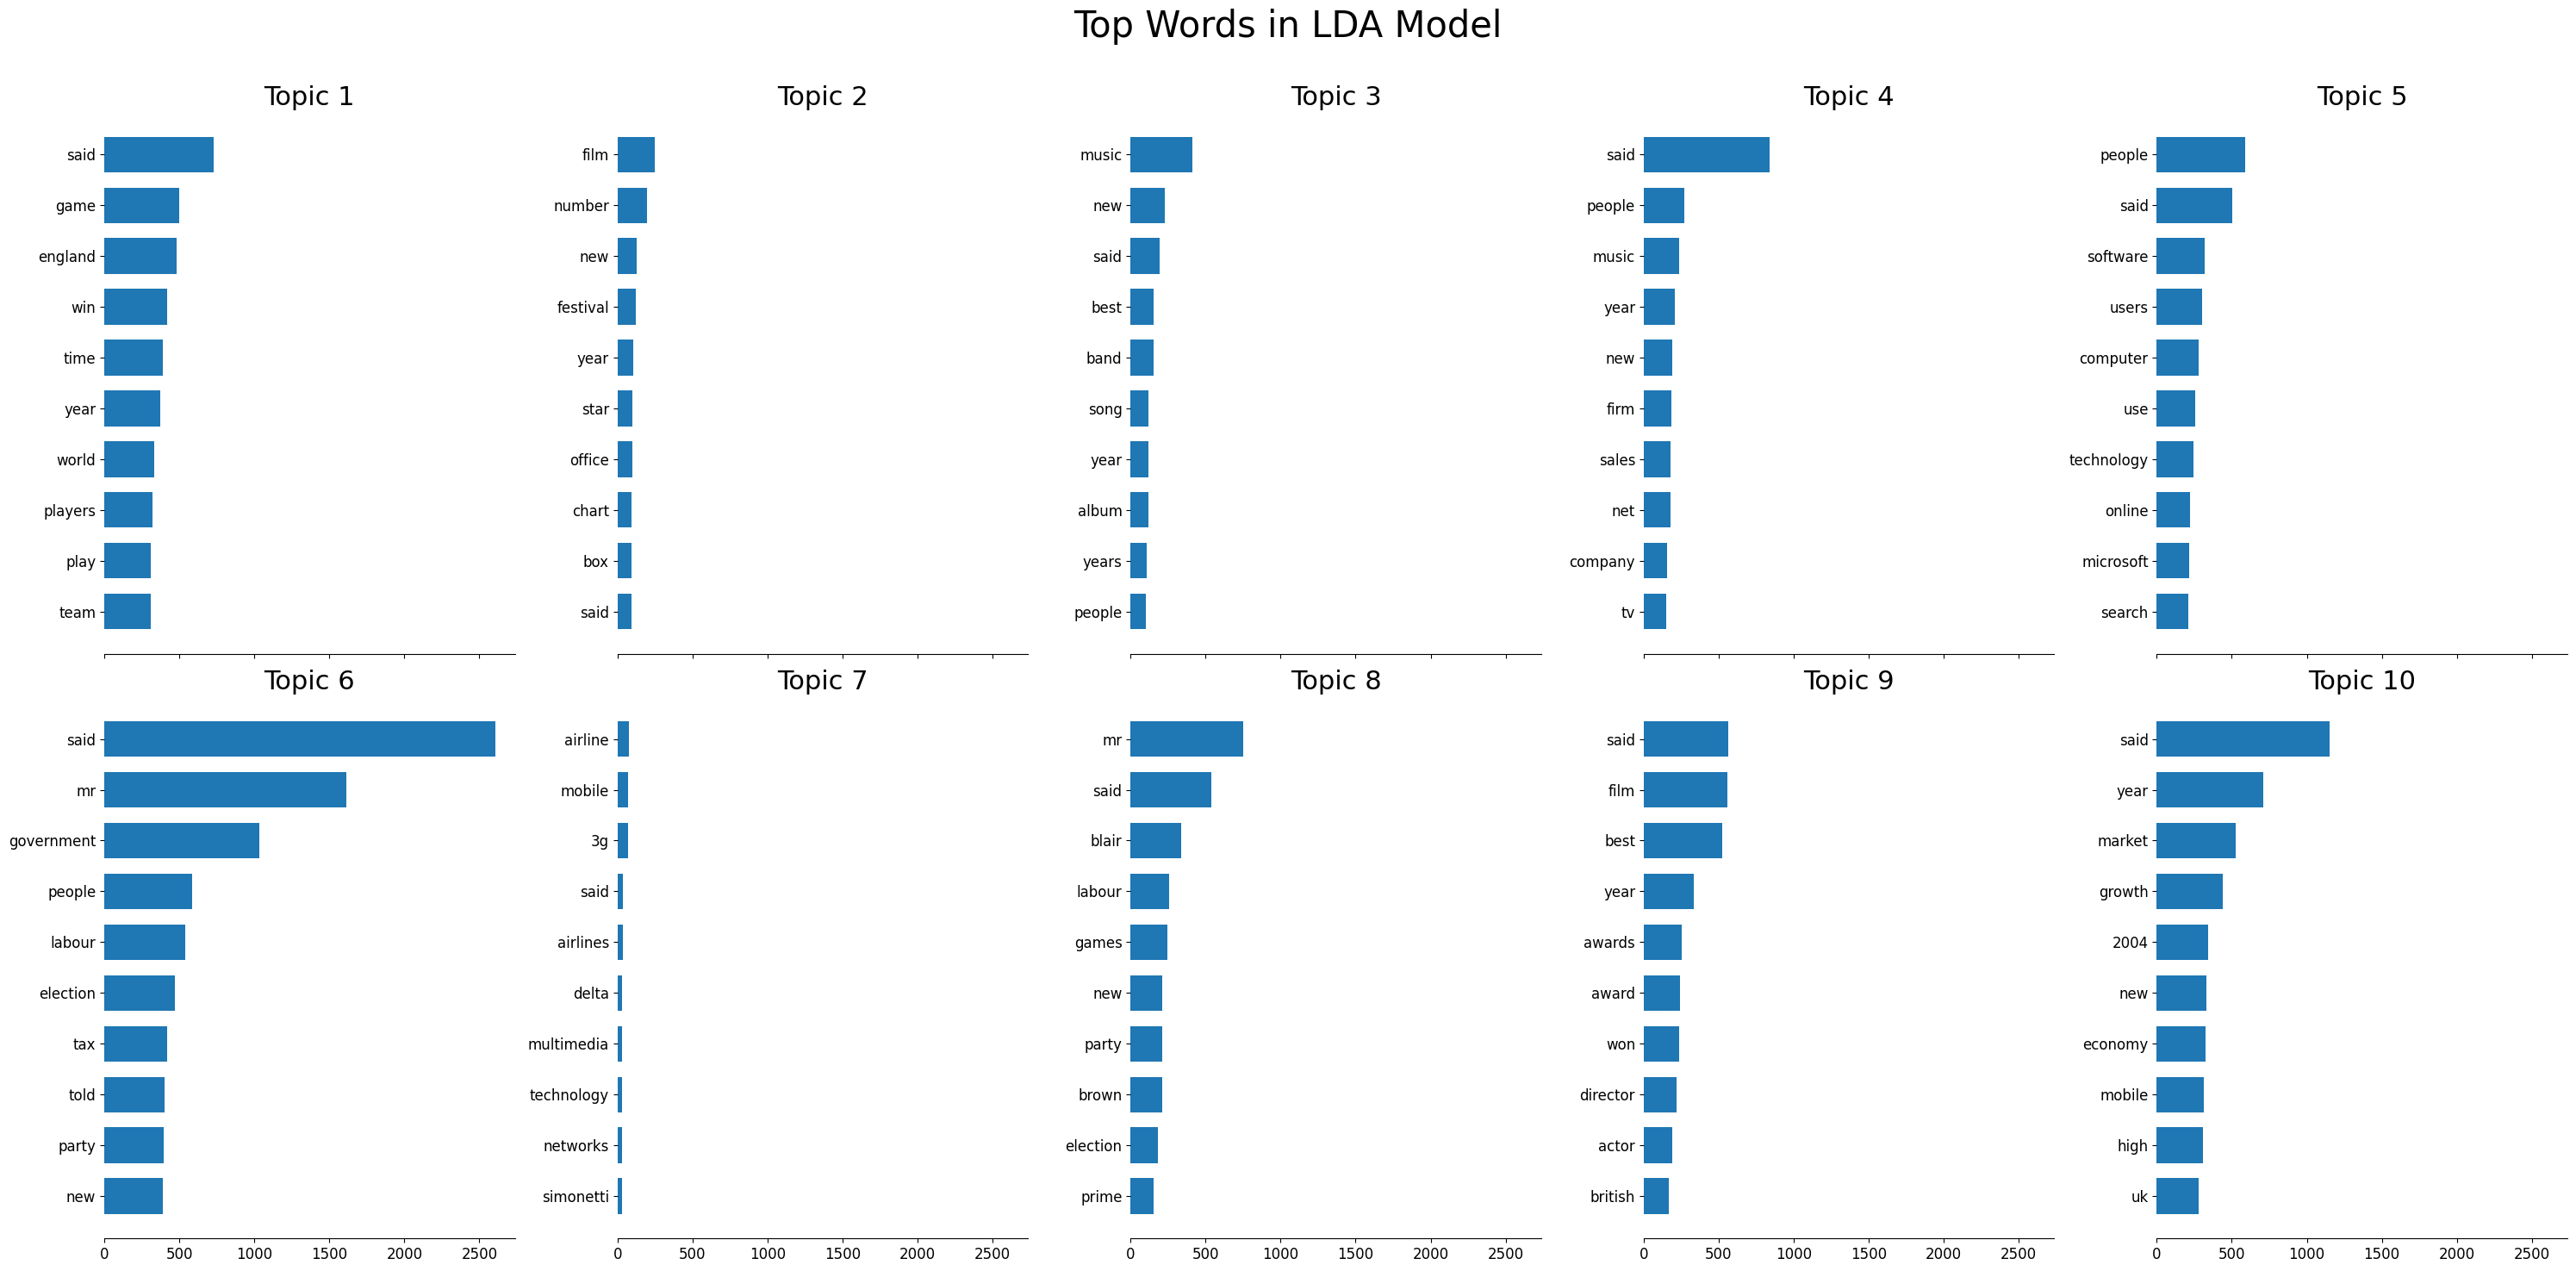

In [33]:
import matplotlib.pyplot as plt

def plot_top_words(model, feature_names, n_top_words=10):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words-1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={'fontsize': 22})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=12)
        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)

    plt.suptitle('Top Words in LDA Model', fontsize=30)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Assuming you have already defined `lda` and `vectorizer`
feature_names = vectorizer.get_feature_names_out()
plot_top_words(lda, feature_names)


In [35]:
Z = lda.transform(X)

Text(0.5, 1.0, 'True Label: sport')

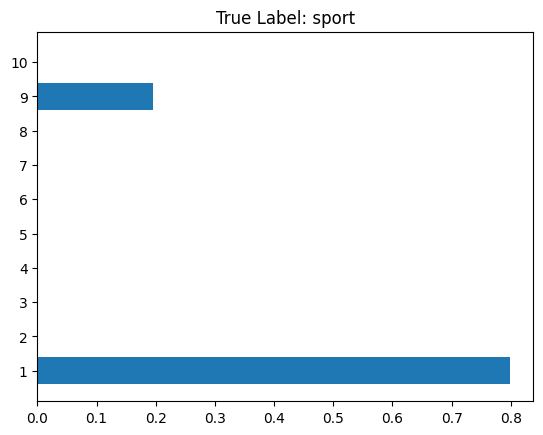

In [37]:
np.random.seed(0)
i = np.random.choice(len(df))
z = Z[i]
topics = np.arange(10) + 1

fig, ax = plt.subplots()
ax.barh(topics, z)
ax.set_yticks(topics)
ax.set_title("True Label: %s"%df.iloc[i]['labels'])

In [38]:
def wrap(x):
  return textwrap.fill(x, replace_whitespace=False, fix_sentence_endings=True)

Text(0.5, 1.0, 'True Label: entertainment')

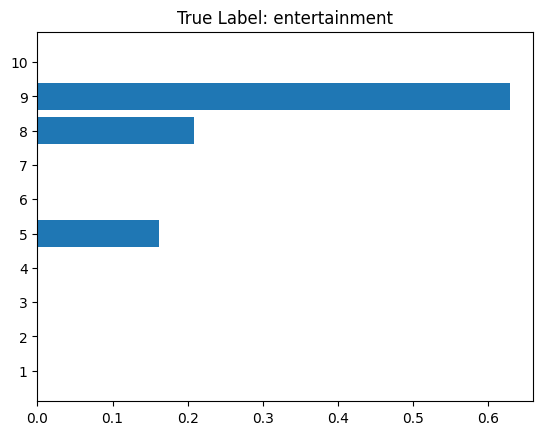

In [39]:
i = np.random.choice(len(df))
z = Z[i]

fig, ax = plt.subplots()
ax.barh(topics, z)
ax.set_yticks(topics)
ax.set_title("True Label: %s"%df.iloc[i]['labels'])